# MIT 805 Big Data Project

### Group 13 Members
1. NB Ndlela (u22848322)
2. TA Molebiemang

### Part 1 – Data Collection & Analysis

### Import Libraries

In [42]:
import urllib.request
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

### Download the 56 zip files in Images_png in batches

In [8]:
#!/usr/bin/env python3
# Download the 56 zip files in Images_png in batches


# URLs for the zip files
#links = [
    #'https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz',
    #'https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz',
    #'https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz',
	#'https://nihcc.box.com/shared/static/0aowwzs5lhjrceb3qp67ahp0rd1l1etg.gz',
    #'https://nihcc.box.com/shared/static/v5e3goj22zr6h8tzualxfsqlqaygfbsn.gz',
	#'https://nihcc.box.com/shared/static/asi7ikud9jwnkrnkj99jnpfkjdes7l6l.gz',
	#'https://nihcc.box.com/shared/static/jn1b4mw4n6lnh74ovmcjb8y48h8xj07n.gz',
    #'https://nihcc.box.com/shared/static/tvpxmn7qyrgl0w8wfh9kqfjskv6nmm1j.gz',
	#'https://nihcc.box.com/shared/static/upyy3ml7qdumlgk2rfcvlb9k6gvqq2pj.gz',
	#'https://nihcc.box.com/shared/static/l6nilvfa9cg3s28tqv1qc1olm3gnz54p.gz',
	#'https://nihcc.box.com/shared/static/hhq8fkdgvcari67vfhs7ppg2w6ni4jze.gz',
	#'https://nihcc.box.com/shared/static/ioqwiy20ihqwyr8pf4c24eazhh281pbu.gz'
#]

#for idx, link in enumerate(links):
    #fn = 'images_%02d.tar.gz' % (idx+1)
    #print('downloading'+fn+'...')
    #urllib.request.urlretrieve(link, fn)  # download the zip file

#print("Download complete. Please check the checksums")///

### Load Metadata

In [15]:
df=pd.read_csv("Data/processing dataset/Data_Entry_2017_v2020.csv")


# Exploratory Data Analysis (EDA)

### Display number of images and unique number of patients for the Raw Dataset

In [16]:
print("Number of images:", len(df))
print("Number of unique patients:", df['Patient ID'].nunique())
df.head()

Number of images: 112120
Number of unique patients: 30805


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


## Keep only metadata for working dataset

In [ ]:
df_subset = df[df['Image Index'].isin(existing_images)]

Number of records in the subset: 34999


### Display number of images and unique number of patients for the Raw Dataset

In [47]:
print("Number of records in the subset:", len(df_subset))
print("Number of unique patients:", df_subset['Patient ID'].nunique())
df_subset.head()

Number of records in the subset: 34999
Number of unique patients: 9232


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


### Data Quality Check

In [48]:
#data overview
df_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 34999 entries, 0 to 34998
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  34999 non-null  str    
 1   Finding Labels               34999 non-null  str    
 2   Follow-up #                  34999 non-null  int64  
 3   Patient ID                   34999 non-null  int64  
 4   Patient Age                  34999 non-null  int64  
 5   Patient Sex                  34999 non-null  str    
 6   View Position                34999 non-null  str    
 7   OriginalImage[Width          34999 non-null  int64  
 8   Height]                      34999 non-null  int64  
 9   OriginalImagePixelSpacing[x  34999 non-null  float64
 10  y]                           34999 non-null  float64
dtypes: float64(2), int64(5), str(4)
memory usage: 2.9 MB


In [49]:
#Missing values
missing_values = df_subset.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Sex                    0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
dtype: int64


In [50]:
#Duplicate Records
duplicate_records = df_subset[df_subset.duplicated()]
print("Number of duplicate records:", len(duplicate_records))

Number of duplicate records: 0


In [51]:
# Verify the existence of image files
image_dir = "Data/processing dataset/images"

existing_images = [f for f in os.listdir(image_dir) if os.path.isfile(os.path.join(image_dir, f))]
print("Number of existing image files:", len(existing_images))


Number of existing image files: 34999


In [52]:
#count unique labels
all_labels= set()
for labels in df_subset['Finding Labels']:
    all_labels.update(labels.split('|'))

print("Number of unique labels:", len(all_labels))
print(sorted(all_labels))

Number of unique labels: 15
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [34]:
df_subset.to_csv("Data/working dataset/df_subset.csv", index=False)

In [35]:
all_labels = set()

for labels in df_subset["Finding Labels"]:
    all_labels.update(labels.split("|"))

diseases = sorted(all_labels)

for disease in diseases:
    df_subset[disease] = df_subset["Finding Labels"].apply(
        lambda x: 1 if disease in x.split("|") else 0
    )

In [36]:
df_subset["Disease_Count"] = (
    df_subset["Finding Labels"]
    .str.split("|")
    .apply(len)
)

In [38]:
print("Rows:", df_subset.shape[0])
print("Columns:", df_subset.shape[1])

print("\nGender Distribution:")
print(df_subset["Patient Sex"].value_counts())

print("\nView Positions:")
print(df_subset["View Position"].value_counts())


Rows: 34999
Columns: 27

Gender Distribution:
Patient Sex
M    18795
F    16204
Name: count, dtype: int64

View Positions:
View Position
PA    21265
AP    13734
Name: count, dtype: int64


### Patient Age Distribution

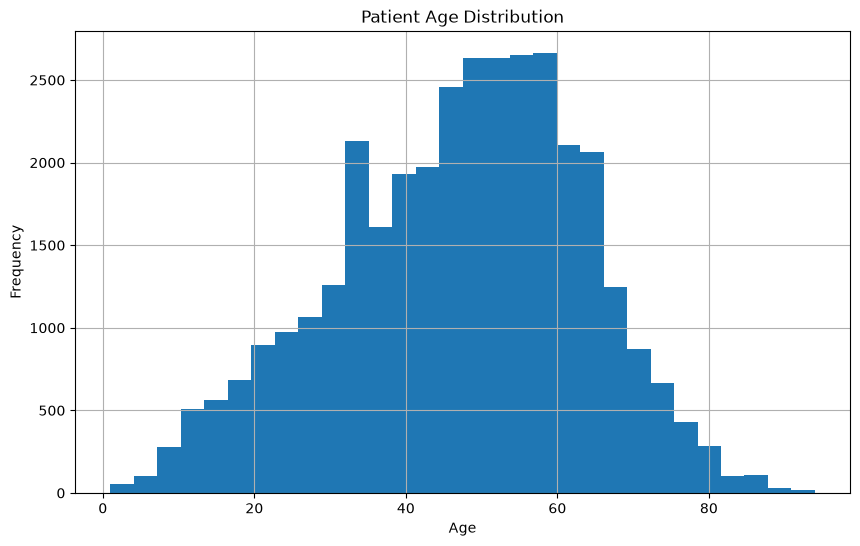

In [39]:
plt.figure(figsize=(10,6))
df_subset["Patient Age"].hist(bins=30)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Disease Frequency

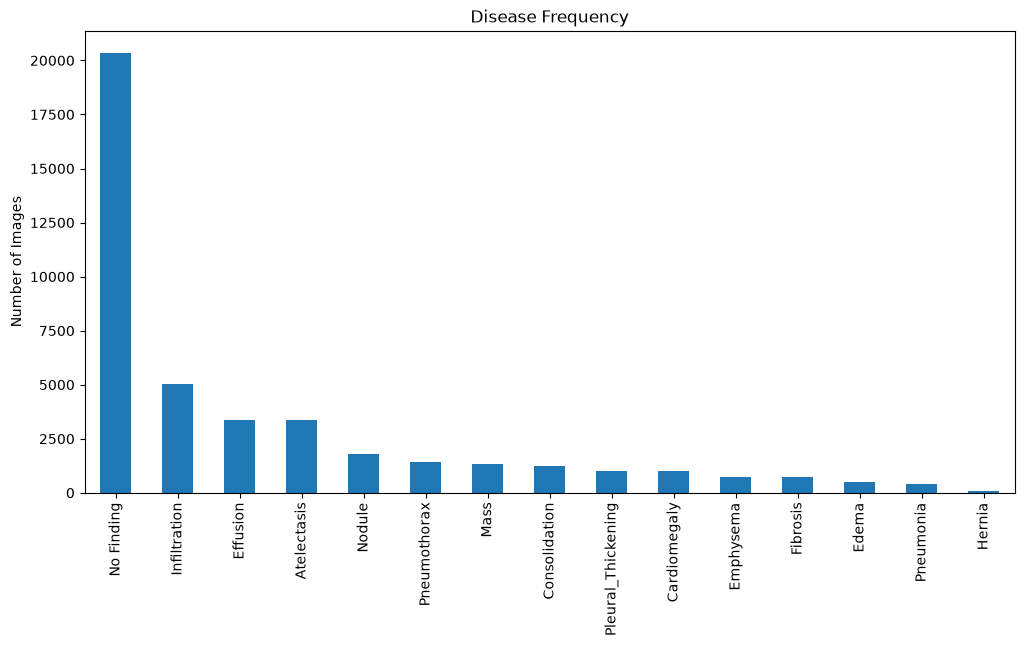

In [41]:
disease_counts = {}

for disease in diseases:
    disease_counts[disease] = df_subset[disease].sum()

disease_counts = pd.Series(disease_counts)

disease_counts.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Disease Frequency")
plt.ylabel("Number of Images")
plt.show()

### images that have diagnoses

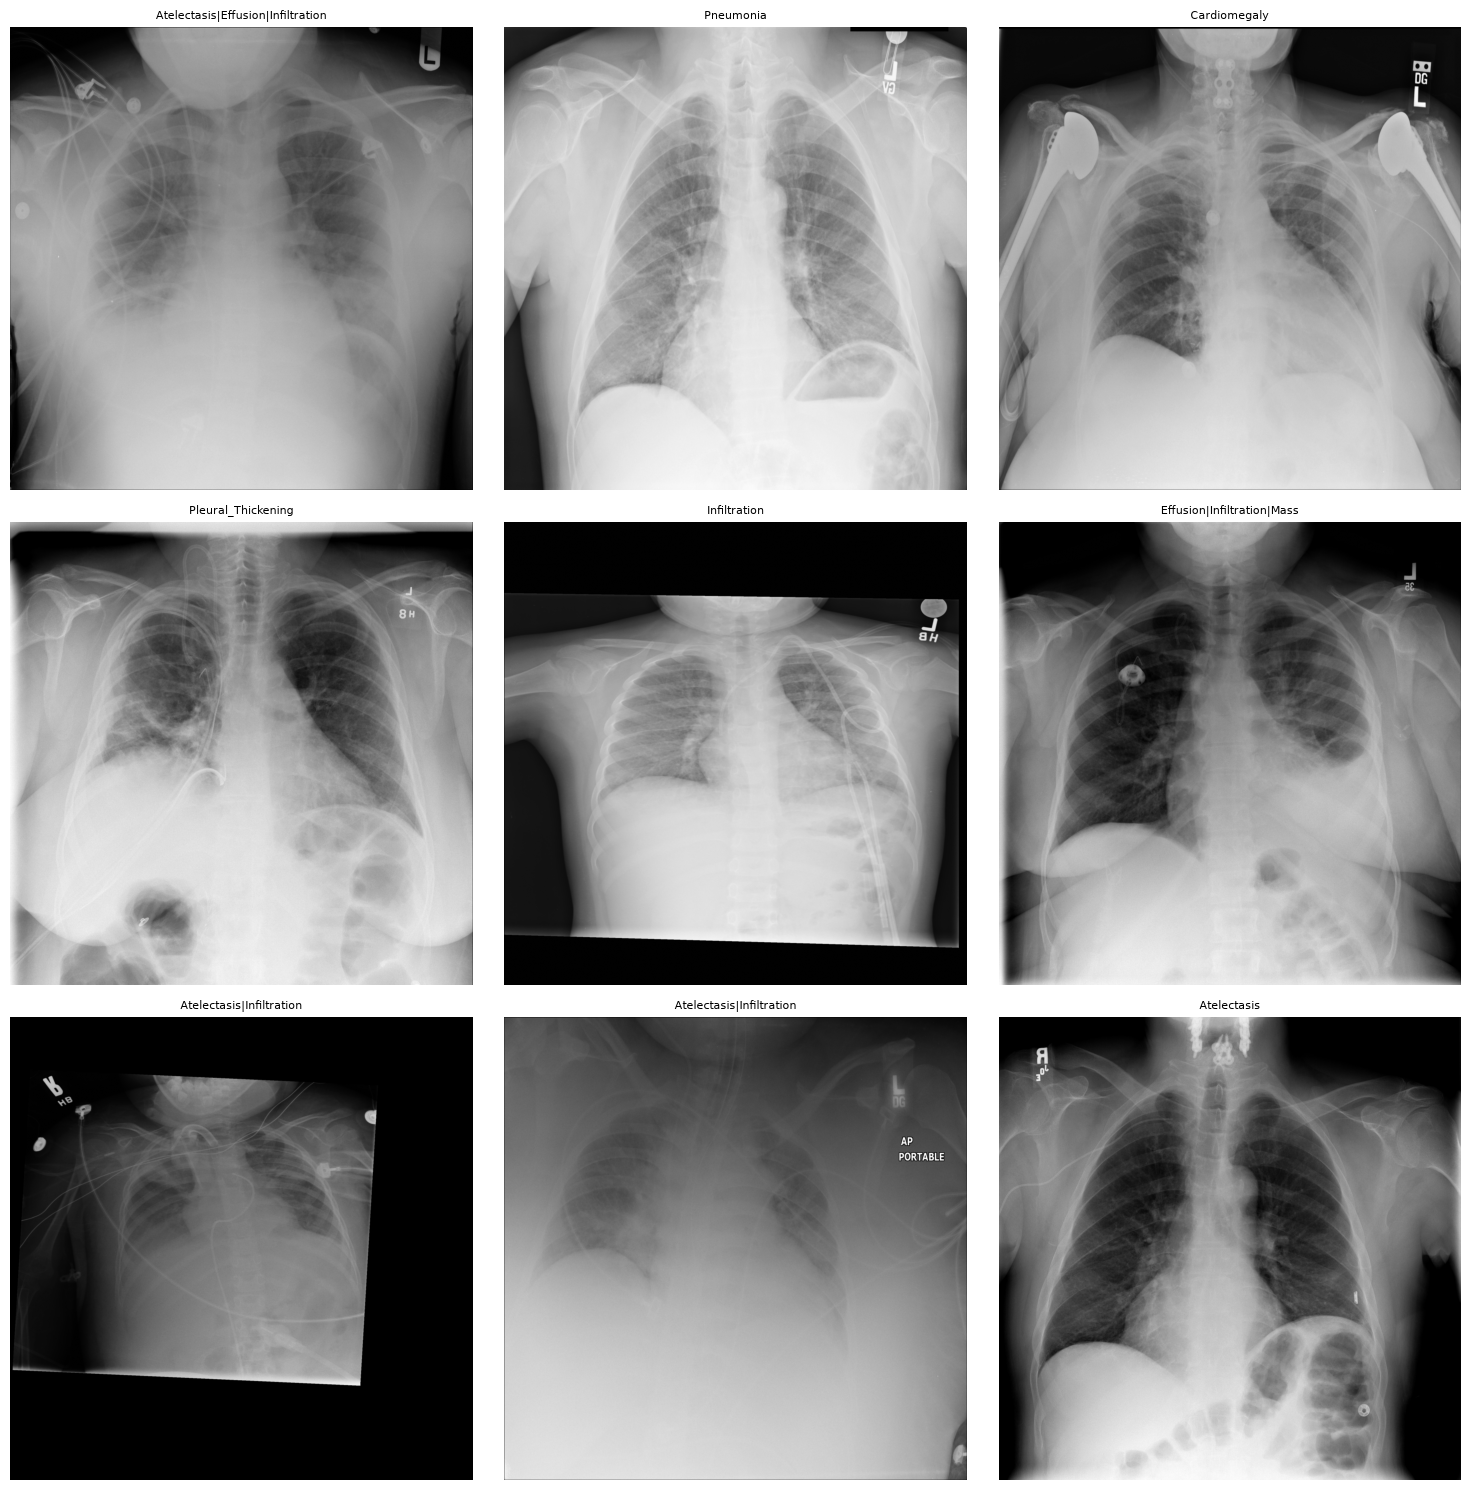

In [ ]:
sample_df = df_subset[
    df_subset["Finding Labels"] != "No Finding"
].sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
    
    img_path = os.path.join(image_dir, row["Image Index"])
    
    img = Image.open(img_path)

    ax.imshow(img, cmap="gray")

    # Show diagnosis as title
    ax.set_title(
        row["Finding Labels"],
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()
plt.show()